In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-41.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-48.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-25.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-45.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-20.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-4.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-38.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-46.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/animals/image-26.png
/kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset/Ai_generated_dataset/an

# Model 1 (CNN replicating Tiny VGG arch)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
torch.manual_seed(42)

In [ ]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

DATASET_PATH = "image_data"

df = datasets.ImageFolder(root=DATASET_PATH, transform=transform)

df

Dataset ImageFolder
    Number of datapoints: 995
    Root location: /kaggle/input/datasets/rhythmghai/ai-vs-real-images-dataset
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [5]:
print(f"Class to Index mapping: {df.class_to_idx}")

Class to Index mapping: {'Ai_generated_dataset': 0, 'real_dataset': 1}


In [6]:
total_size = len(df)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Remainder to avoid rounding errors

# 4. Use random_split to create actual Dataset subsets
train_ds, val_ds, test_ds = random_split(df, [train_size, val_size, test_size])

train_dataloader = DataLoader(train_ds, shuffle=True, batch_size=32)
val_dataloader = DataLoader(val_ds, shuffle=False)
test_dataloader = DataLoader(test_ds, shuffle=False)

print(f"Total Len: {len(df)} || Train Len: {len(train_ds)} || Val Len: {len(val_ds)} || Test Len: {len(test_ds)}")

Total Len: 995 || Train Len: 696 || Val Len: 149 || Test Len: 150


In [7]:
class AiOrReal(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                     out_channels=32,
                     kernel_size=3,
                     stride=1,
                     padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                        stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=32,
                     out_channels=64,
                     kernel_size=3,
                     padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block_3 = nn.Sequential(
            nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=128*28*28,
                     out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128,
                     out_features=output_shape)
        )

    def forward(self, x:torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.classifier(x)

        return x

torch.manual_seed(42)
model = AiOrReal(input_shape=3, hidden_units=32, output_shape=2).to(device)

model

AiOrReal(
  (block_1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=100352, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [8]:
import torchmetrics

epochs = 10

# Move every metric to the device
acc_fn = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
f1_score = torchmetrics.F1Score(task="multiclass", num_classes=2).to(device)
precision_score = torchmetrics.Precision(task="multiclass", num_classes=2).to(device)
recall_score = torchmetrics.Recall(task="multiclass", num_classes=2).to(device)

# Loss functions usually don't need .to(device) unless they have parameters, 
# but it's good practice.
loss = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.001)

In [9]:
import tqdm
import torch
torch.manual_seed(42)
# 1. Train Step
def train_step(model, data_loader, accuracy_fn, f1_score, 
               precision, recall, loss_fn, optimizer, device=device):
    # Initialize trackers
    train_acc, train_loss, train_f1, train_precision, train_recall = 0, 0, 0, 0, 0
    
    model.to(device)
    model.train()

    # Use tqdm for a clean progress bar
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_logits = model(X)
        y_preds = torch.argmax(y_logits, dim=1)
        
        # 2. Calculate loss (for this batch only)
        # Using a unique name like 'batch_loss' prevents overwriting the function
        batch_loss = loss_fn(y_logits, y)

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Backward pass (on the batch tensor)
        batch_loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # 6. Accumulate values using .item() to keep memory low
        train_loss += batch_loss.item()
        train_acc += accuracy_fn(y_preds, y).item()
        train_f1 += f1_score(y_preds, y).item()
        train_precision += precision(y_preds, y).item()
        train_recall += recall(y_preds, y).item()

    # Average metrics over all batches
    n = len(data_loader)
    train_loss /= n
    train_acc /= n
    train_f1 /= n
    train_precision /= n
    train_recall /= n

    print(f"\n[TRAIN] Accuracy: {train_acc:.4f} | Loss: {train_loss:.4f}")
    print(f"Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1: {train_f1:.4f}")

# 2. Eval/Test Step
def test_step(model, data_loader, accuracy_fn, f1_score,
              precision, recall, loss_fn, device=device):
    test_acc, test_loss, test_f1, test_precision, test_recall = 0, 0, 0, 0, 0

    model.to(device)
    model.eval()

    # Inference mode turns off gradients and saves memory
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            y_logits = model(X)
            y_preds = torch.argmax(y_logits, dim=1)

            # Accumulate values using .item()
            test_loss += loss_fn(y_logits, y).item()
            test_acc += accuracy_fn(y_preds, y).item()
            test_f1 += f1_score(y_preds, y).item()
            test_precision += precision(y_preds, y).item()
            test_recall += recall(y_preds, y).item()

    # Average metrics over all batches
    n = len(data_loader)
    test_acc /= n
    test_loss /= n
    test_f1 /= n
    test_precision /= n
    test_recall /= n

    print(f"[TEST]  Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")
    print(f"Precision: {test_precision:.4f} | Recall: {test_recall:.4f} | F1: {test_f1:.4f}")

In [10]:
# Model Training
torch.manual_seed(42)
for epoch in tqdm.tqdm(range(epochs)):
    print(f"===================Epoch: {epoch}========================")

    train_step(model, train_dataloader, acc_fn, f1_score, precision_score, recall_score, loss, optimizer, device)
    test_step(model, test_dataloader, acc_fn, f1_score, precision_score, recall_score, loss, device)

  0%|          | 0/10 [00:00<?, ?it/s]

===================Epoch: 0========================

[TRAIN] Accuracy: 0.6998 | Loss: 0.6679
Precision: 0.6998 | Recall: 0.6998 | F1: 0.6998


 10%|█         | 1/10 [00:29<04:24, 29.43s/it]

[TEST]  Accuracy: 0.7800 | Loss: 0.4740
Precision: 0.7800 | Recall: 0.7800 | F1: 0.7800
===================Epoch: 1========================

[TRAIN] Accuracy: 0.7637 | Loss: 0.5104
Precision: 0.7637 | Recall: 0.7637 | F1: 0.7637


 20%|██        | 2/10 [00:51<03:18, 24.81s/it]

...

[TEST]  Accuracy: 0.8867 | Loss: 0.2901
Precision: 0.8867 | Recall: 0.8867 | F1: 0.8867
===================Epoch: 8========================

[TRAIN] Accuracy: 0.9171 | Loss: 0.1930
Precision: 0.9171 | Recall: 0.9171 | F1: 0.9171


 90%|█████████ | 9/10 [03:21<00:21, 21.62s/it]

[TEST]  Accuracy: 0.9000 | Loss: 0.2929
Precision: 0.9000 | Recall: 0.9000 | F1: 0.9000
===================Epoch: 9========================

[TRAIN] Accuracy: 0.9598 | Loss: 0.1317
Precision: 0.9598 | Recall: 0.9598 | F1: 0.9598


100%|██████████| 10/10 [03:43<00:00, 22.39s/it]

[TEST]  Accuracy: 0.8333 | Loss: 0.4515
Precision: 0.8333 | Recall: 0.8333 | F1: 0.8333


In [11]:
MODEL_PATH = "model_tiny_vgg_cnn.pth"

torch.save(obj=model.state_dict(), f=MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to model_tiny_vgg_cnn.pth


Generating Predictions: 100%|██████████| 150/150 [00:04<00:00, 36.16it/s]


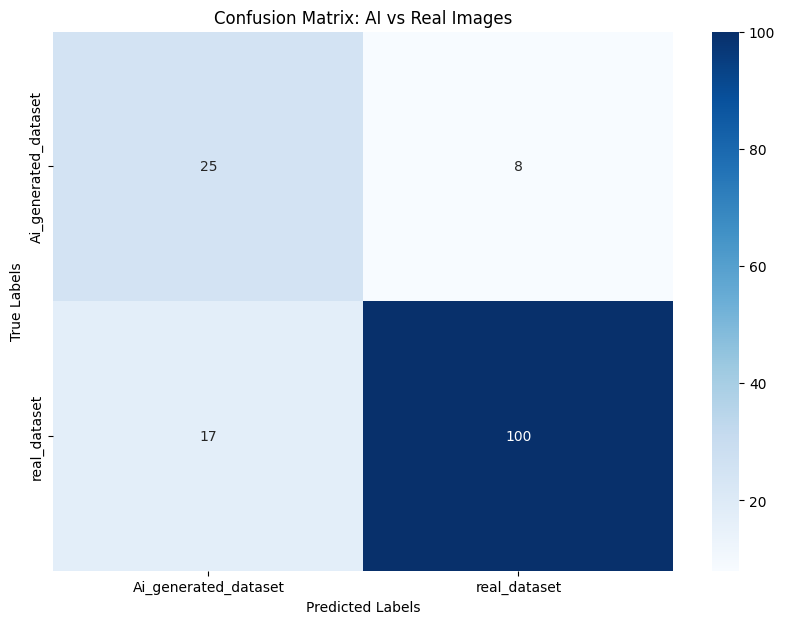

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Collect all predictions and true labels
all_preds = []
all_labels = []

model.eval()
with torch.inference_mode():
    for X, y in tqdm.tqdm(test_dataloader, desc="Generating Predictions"):
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        
        # Move to CPU and convert to list
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# 2. Get class names from the original dataset
class_names = df.classes # ['Ai_generated_dataset', 'real_dataset']

# 3. Compute Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: AI vs Real Images')
plt.show()

# Model 2 (Efficient Net)

In [13]:
from torch.utils.data import ConcatDataset

# Combine the underlying datasets
combined_ds = ConcatDataset([train_ds, val_ds])

# Create a new loader
train_dataloader_combined = DataLoader(combined_ds, batch_size=32, shuffle=True)

In [14]:
import torchvision

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model_1 = torchvision.models.efficientnet_b0(weights=weights).to(device)

# model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 


In [15]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params = model_1.parameters(), lr=0.001)

In [16]:
from torchinfo import summary

summary(model=model_1,
       input_size=(32,3,224,224),
       col_names=["input_size", "output_size", "num_params", "trainable"],
       col_width=20,
       row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [17]:
for param in model_1.features[7:].parameters():
    param.requires_grad = True

In [18]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = 2

model_1.classifier = torch.nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=512),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=0.3),
    torch.nn.Linear(in_features=512, out_features=2)
).to(device)

In [19]:
# After freezing the features and changing the output

summary(model_1, 
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 2]              --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [20]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for epoch in tqdm.tqdm(range(10)):
    # print(f"\nEpoch: {epoch} ------------------")
    
    # Use the train_step we defined earlier
    train_step(model=model_1, 
               data_loader=train_dataloader,
               accuracy_fn=acc_fn, 
               f1_score=f1_score, 
               precision=precision_score, 
               recall=recall_score, 
               loss_fn=loss, 
               optimizer=optimizer, 
               device=device)
    
    # Use the test_step for validation
    test_step(model=model_1, 
              data_loader=val_dataloader, 
              accuracy_fn=acc_fn, 
              f1_score=f1_score, 
              precision=precision_score, 
              recall=recall_score, 
              loss_fn=loss, 
              device=device)

  0%|          | 0/10 [00:00<?, ?it/s]


[TRAIN] Accuracy: 0.8996 | Loss: 0.3722
Precision: 0.8996 | Recall: 0.8996 | F1: 0.8996


 10%|█         | 1/10 [00:25<03:46, 25.20s/it]

[TEST]  Accuracy: 0.9866 | Loss: 0.0502
Precision: 0.9866 | Recall: 0.9866 | F1: 0.9866

[TRAIN] Accuracy: 0.9564 | Loss: 0.1500
Precision: 0.9564 | Recall: 0.9564 | F1: 0.9564


 20%|██        | 2/10 [00:49<03:16, 24.60s/it]

...

[TEST]  Accuracy: 0.9732 | Loss: 0.0715
Precision: 0.9732 | Recall: 0.9732 | F1: 0.9732

[TRAIN] Accuracy: 0.9886 | Loss: 0.0601
Precision: 0.9886 | Recall: 0.9886 | F1: 0.9886


 90%|█████████ | 9/10 [03:39<00:24, 24.34s/it]

[TEST]  Accuracy: 0.9866 | Loss: 0.0520
Precision: 0.9866 | Recall: 0.9866 | F1: 0.9866

[TRAIN] Accuracy: 0.9853 | Loss: 0.0735
Precision: 0.9853 | Recall: 0.9853 | F1: 0.9853


100%|██████████| 10/10 [04:03<00:00, 24.33s/it]

[TEST]  Accuracy: 0.9732 | Loss: 0.0848
Precision: 0.9732 | Recall: 0.9732 | F1: 0.9732


In [21]:
MODEL_PATH = "model_1_resnet_b0.pth"

torch.save(obj=model_1.state_dict(), f=MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to model_1_resnet_b0.pth


Generating Predictions: 100%|██████████| 150/150 [00:05<00:00, 29.91it/s]


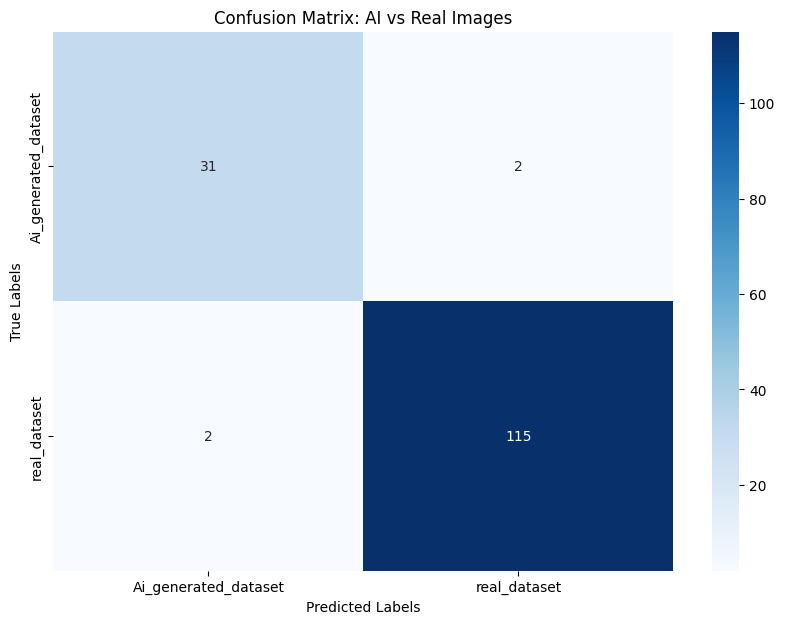

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Collect all predictions and true labels
all_preds = []
all_labels = []

model_1.eval()
with torch.inference_mode():
    for X, y in tqdm.tqdm(test_dataloader, desc="Generating Predictions"):
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        logits = model_1(X)
        preds = torch.argmax(logits, dim=1)
        
        # Move to CPU and convert to list
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# 2. Get class names from the original dataset
class_names = df.classes # ['Ai_generated_dataset', 'real_dataset']

# 3. Compute Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: AI vs Real Images')
plt.show()

# Model 3 which is ViT

In [23]:
# ViT
weights_2 = torchvision.models.ViT_B_16_Weights.DEFAULT
model_2 = torchvision.models.vit_b_16(weights=weights_2).to(device)

vit_transforms = weights_2.transforms()
print(f"ViT required transforms: {vit_transforms}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 169MB/s]


ViT required transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [24]:
df = datasets.ImageFolder(root=DATASET_PATH, transform=vit_transforms)

total_size = len(df)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Remainder to avoid rounding errors

# 4. Use random_split to create actual Dataset subsets
train_ds, val_ds, test_ds = random_split(df, [train_size, val_size, test_size])

train_dataloader = DataLoader(train_ds, shuffle=True, batch_size=32)
val_dataloader = DataLoader(val_ds, shuffle=False)
test_dataloader = DataLoader(test_ds, shuffle=False)

print(f"Total Len: {len(df)} || Train Len: {len(train_ds)} || Val Len: {len(val_ds)} || Test Len: {len(test_ds)}")

Total Len: 995 || Train Len: 696 || Val Len: 149 || Test Len: 150


In [25]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params = model_2.parameters(), lr=0.001)

In [26]:
for param in model_2.encoder.layers[11].parameters():
    param.requires_grad = True

In [27]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = 2

model_2.heads = torch.nn.Sequential(
    torch.nn.Linear(in_features=768, 
                   out_features=output_shape)
).to(device)

In [28]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for epoch in tqdm.tqdm(range(10)):
    # print(f"\nEpoch: {epoch} ------------------")
    
    # Use the train_step we defined earlier
    train_step(model=model_2, 
               data_loader=train_dataloader,
               accuracy_fn=acc_fn, 
               f1_score=f1_score, 
               precision=precision_score, 
               recall=recall_score, 
               loss_fn=loss, 
               optimizer=optimizer, 
               device=device)
    
    # Use the test_step for validation
    test_step(model=model_2, 
              data_loader=val_dataloader, 
              accuracy_fn=acc_fn, 
              f1_score=f1_score, 
              precision=precision_score, 
              recall=recall_score, 
              loss_fn=loss, 
              device=device)

  0%|          | 0/10 [00:00<?, ?it/s]


[TRAIN] Accuracy: 0.6709 | Loss: 0.9565
Precision: 0.6709 | Recall: 0.6709 | F1: 0.6709


 10%|█         | 1/10 [00:48<07:14, 48.29s/it]

[TEST]  Accuracy: 0.7584 | Loss: 0.5641
Precision: 0.7584 | Recall: 0.7584 | F1: 0.7584

[TRAIN] Accuracy: 0.7533 | Loss: 0.5945
Precision: 0.7533 | Recall: 0.7533 | F1: 0.7533


 20%|██        | 2/10 [01:34<06:18, 47.32s/it]

...

[TEST]  Accuracy: 0.8188 | Loss: 0.3979
Precision: 0.8188 | Recall: 0.8188 | F1: 0.8188

[TRAIN] Accuracy: 0.7746 | Loss: 0.4467
Precision: 0.7746 | Recall: 0.7746 | F1: 0.7746


 90%|█████████ | 9/10 [07:08<00:47, 47.61s/it]

[TEST]  Accuracy: 0.7651 | Loss: 0.5047
Precision: 0.7651 | Recall: 0.7651 | F1: 0.7651

[TRAIN] Accuracy: 0.8291 | Loss: 0.3873
Precision: 0.8291 | Recall: 0.8291 | F1: 0.8291


100%|██████████| 10/10 [07:55<00:00, 47.54s/it]

[TEST]  Accuracy: 0.7852 | Loss: 0.4263
Precision: 0.7852 | Recall: 0.7852 | F1: 0.7852


In [29]:
MODEL_PATH = "model_2_ViT_b16.pth"

torch.save(obj=model_2.state_dict(), f=MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to model_2_ViT_b16.pth


Generating Predictions: 100%|██████████| 150/150 [00:05<00:00, 27.75it/s]


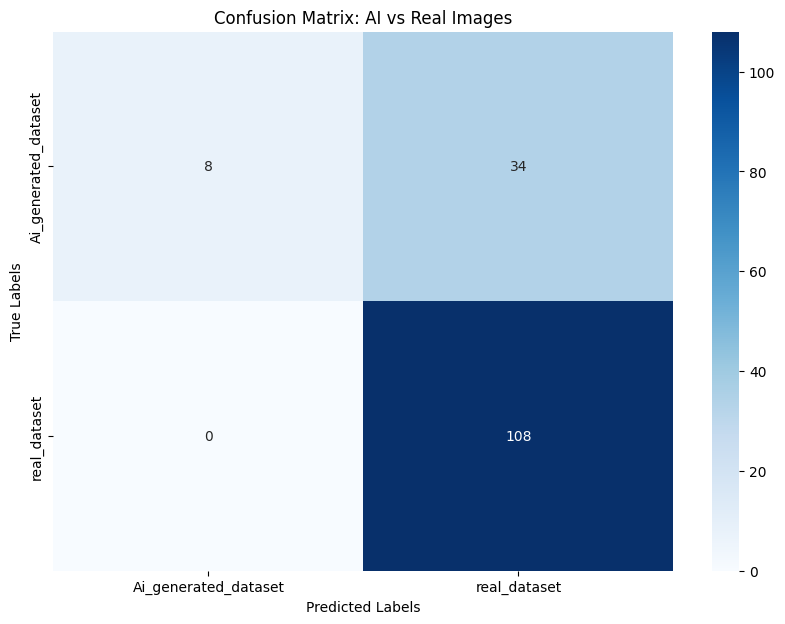

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Collect all predictions and true labels
all_preds = []
all_labels = []

model_2.eval()
with torch.inference_mode():
    for X, y in tqdm.tqdm(test_dataloader, desc="Generating Predictions"):
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        logits = model_2(X)
        preds = torch.argmax(logits, dim=1)
        
        # Move to CPU and convert to list
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# 2. Get class names from the original dataset
class_names = df.classes # ['Ai_generated_dataset', 'real_dataset']

# 3. Compute Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: AI vs Real Images')
plt.show()

# Model 4 (Hybridised EfficientNet*ViT)

In [31]:
class AIHybrid(nn.Module):
    def __init__(self, model_1, model_2):
        super().__init__()

        self.res_backbone = model_1.features
        self.res_pool = nn.AdaptiveAvgPool2d(1)

        self.vit_backbone = model_2

        # Combined Brain
        self.meta_classifier = nn.Sequential(
            nn.Linear(1280+768, 512),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        # 1. RES Path
        res_features = self.res_backbone(x)
        res_features = self.res_pool(res_features)
        res_features = torch.flatten(res_features, 1)

        # 2. ViT Path (Fixed)
        # Process image into patches
        x_vit = self.vit_backbone._process_input(x) # [batch, 196, 768]
        n = x_vit.shape[0]

        # Expand the [CLS] token to match batch size and prepend it
        batch_class_token = self.vit_backbone.class_token.expand(n, -1, -1) # [batch, 1, 768]
        x_vit = torch.cat([batch_class_token, x_vit], dim=1) # Now [batch, 197, 768]

        # Pass through the encoder (this is where it was failing)
        vit_features = self.vit_backbone.encoder(x_vit) 
        
        # Take only the [CLS] token output for classification
        vit_features = vit_features[:, 0] # [batch, 768]

        # 3. Fusion Path
        # ERROR CHECK: Make sure you use 'combined_feat' consistently
        combined_feat = torch.cat((res_features, vit_features), dim=1)

        return self.meta_classifier(combined_feat)

model_3 = AIHybrid(model_1, model_2).to(device)

In [32]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for epoch in tqdm.tqdm(range(10)):
    
    # Use the train_step we defined earlier
    train_step(model=model_3, 
               data_loader=train_dataloader,
               accuracy_fn=acc_fn, 
               f1_score=f1_score, 
               precision=precision_score, 
               recall=recall_score, 
               loss_fn=loss, 
               optimizer=optimizer, 
               device=device)
    
    # Use the test_step for validation
    test_step(model=model_3, 
              data_loader=val_dataloader, 
              accuracy_fn=acc_fn, 
              f1_score=f1_score, 
              precision=precision_score, 
              recall=recall_score, 
              loss_fn=loss, 
              device=device)

  0%|          | 0/10 [00:00<?, ?it/s]


[TRAIN] Accuracy: 0.7505 | Loss: 0.5352
Precision: 0.7505 | Recall: 0.7505 | F1: 0.7505


 10%|█         | 1/10 [00:52<07:51, 52.42s/it]

[TEST]  Accuracy: 0.8188 | Loss: 0.3716
Precision: 0.8188 | Recall: 0.8188 | F1: 0.8188

[TRAIN] Accuracy: 0.8390 | Loss: 0.3732
Precision: 0.8390 | Recall: 0.8390 | F1: 0.8390


 20%|██        | 2/10 [01:44<06:58, 52.37s/it]

...

[TEST]  Accuracy: 0.9732 | Loss: 0.2201
Precision: 0.9732 | Recall: 0.9732 | F1: 0.9732

[TRAIN] Accuracy: 0.9418 | Loss: 0.1925
Precision: 0.9418 | Recall: 0.9418 | F1: 0.9418


 90%|█████████ | 9/10 [07:53<00:52, 52.81s/it]

[TEST]  Accuracy: 0.9597 | Loss: 0.1910
Precision: 0.9597 | Recall: 0.9597 | F1: 0.9597

[TRAIN] Accuracy: 0.9583 | Loss: 0.1767
Precision: 0.9583 | Recall: 0.9583 | F1: 0.9583


100%|██████████| 10/10 [08:45<00:00, 52.55s/it]

[TEST]  Accuracy: 0.9463 | Loss: 0.2089
Precision: 0.9463 | Recall: 0.9463 | F1: 0.9463


In [33]:
MODEL_PATH = "model_3_Hybrid.pth"

torch.save(obj=model_3.state_dict(), f=MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to model_3_Hybrid.pth


Generating Predictions: 100%|██████████| 150/150 [00:06<00:00, 22.23it/s]


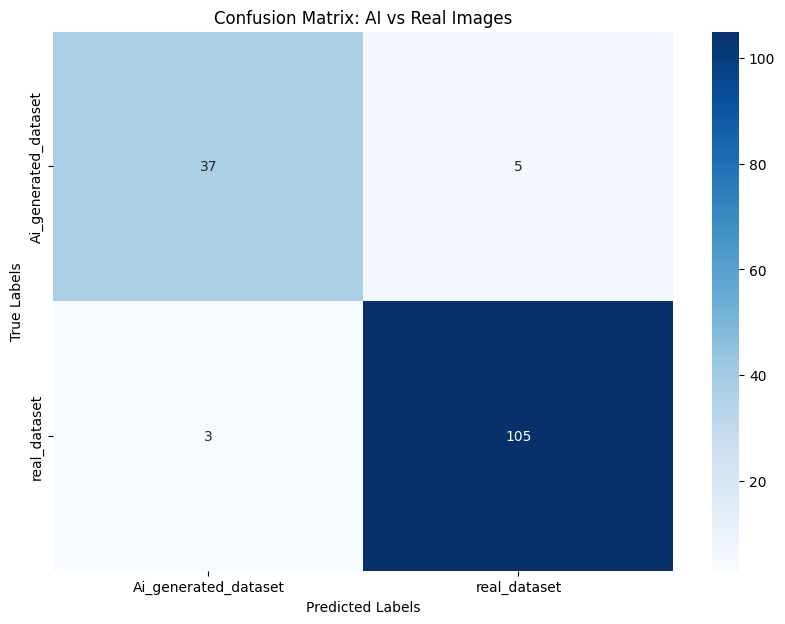

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Collect all predictions and true labels
all_preds = []
all_labels = []

model_3.eval()
with torch.inference_mode():
    for X, y in tqdm.tqdm(test_dataloader, desc="Generating Predictions"):
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        logits = model_3(X)
        preds = torch.argmax(logits, dim=1)
        
        # Move to CPU and convert to list
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# 2. Get class names from the original dataset
class_names = df.classes # ['Ai_generated_dataset', 'real_dataset']

# 3. Compute Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix: AI vs Real Images')
plt.show()